In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [2]:
!pip install dagshub mlflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 76.2 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 71.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 40.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import dagshub
import mlflow

dagshub.init(repo_owner='lshek22', repo_name='IEEE-CIS-Fraud-Detection', mlflow=True)
mlflow.set_experiment("XGBoost_Training")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=7df9d8d6-7bbc-4631-b5f6-f5fb72001dda&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=d582eaabf7d7b42590bfdb86a13e62915cfbb861fbefdc0d5724fe94e97ea404




Accessing as lshek22

Initialized MLflow to track repo "lshek22/IEEE-CIS-Fraud-Detection"

Repository lshek22/IEEE-CIS-Fraud-Detection initialized!

<Experiment: artifact_location='mlflow-artifacts:/5c5b6c2f00f748db864cd7ddb636e295', creation_time=1777893686002, experiment_id='0', last_update_time=1777893686002, lifecycle_stage='active', name='XGBoost_Training', tags={'mlflow.experimentKind': 'custom_model_development'}, trace_location=None, workspace='default'>

In [4]:
train = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv').merge(
        pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv'), on='TransactionID', how='left')
test = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv').merge(
       pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv'), on='TransactionID', how='left')


with mlflow.start_run(run_name = "XGBoost_Cleaning"):
    null_count = train.isnull().mean()
    cols_to_drop = [column for column in null_count[null_count > 0.5].index if column != 'isFraud']

    train.drop(columns=cols_to_drop, inplace=True)
    test.drop(columns=[c for c in cols_to_drop if c in test.columns], inplace=True)
    
    test_ids = test['TransactionID'].copy()
    train.drop(columns=['TransactionID'], inplace=True)
    test.drop(columns=['TransactionID'], inplace=True)

    mlflow.log_params({
        "null_threshold": 0.5,
        "original_col_count": train.shape[1] + len(cols_to_drop),
        "dropped_cols_count": len(cols_to_drop),
        "final_col_count": train.shape[1]
    })
    print(f"remaining features: {train.shape[1]}")

remaining features: 219
🏃 View run XGBoost_Cleaning at: https://dagshub.com/lshek22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/442981480e964ca49beedfb4c9677022
🧪 View experiment at: https://dagshub.com/lshek22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


In [5]:
with mlflow.start_run(run_name="XGBoost_Feature_Engineering"):
    for df in [train, test]:
        df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])
        
        df['Transaction_hour'] = (df['TransactionDT'] / 3600) % 24
        df['Transaction_day']  = (df['TransactionDT'] / (3600 * 24)) % 7
        
        if 'D1' in df.columns:
            df['D1_normalized'] = df['TransactionDT'] / (3600 * 24) - df['D1']

        if 'P_emaildomain' in df.columns and 'R_emaildomain' in df.columns:
            df['email_match'] = (df['P_emaildomain'] == df['R_emaildomain']).astype(int)
        
        
        for col in ['card1', 'card2', 'addr1']:
            if col in df.columns:
                df[f'{col}_freq'] = df[col].map(train[col].value_counts()).fillna(0)

    mlflow.log_param("engineered_features", "log_amt, hour, day, D1_norm, email_match, freq_encding")
    print(f"shape: {train.shape}")

shape: (590540, 226)
🏃 View run XGBoost_Feature_Engineering at: https://dagshub.com/lshek22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/a9800b01d8ba4a45ad6856d2adbe0482
🧪 View experiment at: https://dagshub.com/lshek22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


In [6]:
with mlflow.start_run(run_name="XGBoost_Feature_Selection"):
    num_cols = train.select_dtypes(exclude='object').columns.tolist()
    
    corr_matrix = train[num_cols].drop(columns=['isFraud'], errors='ignore').corr().abs()
    
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    all_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
    
    train.drop(columns=all_drop, inplace=True)
    test.drop(columns=[c for c in all_drop if c in test.columns], inplace=True)
    
    mlflow.log_params({
        'corr_threshold': 0.85,
        'cols_dropped_count': len(all_drop),
        'final_feature_count': train.shape[1] - 1
    })
    
    print(f"dropped {len(all_drop)} features")
    print(f"shape: {train.shape}")

dropped 115 features
shape: (590540, 111)
🏃 View run XGBoost_Feature_Selection at: https://dagshub.com/lshek22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/7d8c47bf2c4241fba2d464f46d210560
🧪 View experiment at: https://dagshub.com/lshek22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


In [7]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import roc_auc_score
import numpy as np
import mlflow

X = train.drop(columns=['isFraud'])
y = train['isFraud']

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scale_pos_weight = (y == 0).sum() / (y == 1).sum()

preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ]), cat_cols)
])

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

with mlflow.start_run(run_name="XGB_Baseline_With_CV"):
    full_pipeline = Pipeline([
        ('pre', preprocessor),
        ('model', XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            scale_pos_weight=scale_pos_weight,
            tree_method='hist',
            random_state=42,
            n_jobs=-1
        ))
    ])

    cv_scores = cross_val_score(full_pipeline, X_train, y_train, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
    
    full_pipeline.fit(X_train, y_train)
    
    train_auc = roc_auc_score(y_train, full_pipeline.predict_proba(X_train)[:, 1])
    val_auc = roc_auc_score(y_val, full_pipeline.predict_proba(X_val)[:, 1])

    mlflow.log_params({"n_estimators": 200, "max_depth": 6, "cv_folds": 5})
    mlflow.log_metrics({
        "train_auc": train_auc,
        "val_auc": val_auc,
        "cv_auc_mean": cv_scores.mean(),
        "cv_auc_std": cv_scores.std(),
        "overfit_gap": train_auc - cv_scores.mean()
    })
    
    
    mlflow.xgboost.log_model(full_pipeline.named_steps['model'], artifact_path="model")

    

    print(f"train AUC: {train_auc:.4f} --- val AUC: {val_auc:.4f}")

2026/05/05 16:19:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


train AUC: 0.9609 --- val AUC: 0.9396
🏃 View run XGB_Baseline_With_CV at: https://dagshub.com/lshek22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/c0c35c30bcbe4defb144f065c26af122
🧪 View experiment at: https://dagshub.com/lshek22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


In [8]:
def log_run(run_name, model, params, registered_model_name=None):
    with mlflow.start_run(run_name=run_name):
        p = Pipeline([('pre', preprocessor), ('model', model)])
        
        p.fit(X_train, y_train)
        
        tr_auc = roc_auc_score(y_train, p.predict_proba(X_train)[:,1])
        vl_auc = roc_auc_score(y_val,   p.predict_proba(X_val)[:,1])
        
        cv_s = cross_val_score(p, X_train, y_train, cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
        
        mlflow.log_params(params)
        mlflow.log_metrics({
            'train_auc': tr_auc,
            'val_auc': vl_auc,
            'cv_auc_mean': cv_s.mean(),
            'overfit_gap': tr_auc - cv_s.mean()
        })
        
        mlflow.sklearn.log_model(sk_model=p, name="model", registered_model_name=registered_model_name)
        print(f'{run_name:45s} train={tr_auc:.4f} val={vl_auc:.4f} cv={cv_s.mean():.4f}')
        return p, vl_auc

In [9]:
neg = (y == 0).sum()
pos = (y == 1).sum()
spw = neg / pos

p1,a1 = log_run('XGB_baseline_no_weight',
    XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                  eval_metric='auc', random_state=42, n_jobs=-1),
    {'n_estimators':100,'learning_rate':0.1,'max_depth':6,'scale_pos_weight':1,'note':'no_imbalance_handling'},
               registered_model_name="XGB_baseline_no_weight")

2026/05/05 16:21:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'XGB_baseline_no_weight'.
2026/05/05 16:21:42 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: XGB_baseline_no_weight, version 1
Created version '1' of model 'XGB_baseline_no_weight'.


XGB_baseline_no_weight                        train=0.9354 val=0.9232 cv=0.9200
🏃 View run XGB_baseline_no_weight at: https://dagshub.com/lshek22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/b1bdb61b6d164896872a521ed65104c2
🧪 View experiment at: https://dagshub.com/lshek22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


In [10]:
p2,a2 = log_run('XGB_scale_pos_weight',
    XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                  scale_pos_weight=spw, eval_metric='auc', random_state=42, n_jobs=-1),
    {'n_estimators':100,'learning_rate':0.1,'max_depth':6,'scale_pos_weight':round(spw,1)},
               registered_model_name="XGB_scale_pos_weight")

2026/05/05 16:23:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'XGB_scale_pos_weight' already exists. Creating a new version of this model...
2026/05/05 16:23:20 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: XGB_scale_pos_weight, version 1
Created version '1' of model 'XGB_scale_pos_weight'.


XGB_scale_pos_weight                          train=0.9397 val=0.9253 cv=0.9238
🏃 View run XGB_scale_pos_weight at: https://dagshub.com/lshek22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/01f98681acee4639bc2c346cc730d29b
🧪 View experiment at: https://dagshub.com/lshek22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


In [11]:
p3,a3 = log_run('XGB_learning_rate_0.05_n200',
    XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6,
                  scale_pos_weight=spw, eval_metric='auc', random_state=42, n_jobs=-1),
    {'n_estimators':200,'learning_rate':0.05,'max_depth':6,'scale_pos_weight':round(spw,1)},
               registered_model_name="XGB_learning_rate_0.05_n200")

2026/05/05 16:25:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'XGB_learning_rate_0.05_n200'.
2026/05/05 16:25:28 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: XGB_learning_rate_0.05_n200, version 1
Created version '1' of model 'XGB_learning_rate_0.05_n200'.


XGB_learning_rate_0.05_n200                   train=0.9386 val=0.9245 cv=0.9231
🏃 View run XGB_learning_rate_0.05_n200 at: https://dagshub.com/lshek22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/eec548d4b7c245ada37df10c58f3af57
🧪 View experiment at: https://dagshub.com/lshek22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


In [12]:
p4,a4 = log_run('XGB_depth3_underfit',
    XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3,
                  scale_pos_weight=spw, eval_metric='auc', random_state=42, n_jobs=-1),
    {'n_estimators':100,'learning_rate':0.1,'max_depth':3,'scale_pos_weight':round(spw,1),'note':'shallow_underfit'},
               registered_model_name="XGB_depth3_underfit")

2026/05/05 16:26:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'XGB_depth3_underfit'.
2026/05/05 16:26:53 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: XGB_depth3_underfit, version 1
Created version '1' of model 'XGB_depth3_underfit'.


XGB_depth3_underfit                           train=0.8913 val=0.8868 cv=0.8874
🏃 View run XGB_depth3_underfit at: https://dagshub.com/lshek22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/22212b44e0944ba39f106ce48fbd9eb7
🧪 View experiment at: https://dagshub.com/lshek22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


In [13]:
p5,a5 = log_run('XGB_subsample_colsample',
    XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6,
                  subsample=0.8, colsample_bytree=0.8,
                  scale_pos_weight=spw, eval_metric='auc', random_state=42, n_jobs=-1),
    {'n_estimators':200,'learning_rate':0.05,'max_depth':6,
     'subsample':0.8,'colsample_bytree':0.8,'scale_pos_weight':round(spw,1)},
               registered_model_name="XGB_subsample_colsample")

2026/05/05 16:28:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'XGB_subsample_colsample'.
2026/05/05 16:29:04 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: XGB_subsample_colsample, version 1
Created version '1' of model 'XGB_subsample_colsample'.


XGB_subsample_colsample                       train=0.9439 val=0.9289 cv=0.9268
🏃 View run XGB_subsample_colsample at: https://dagshub.com/lshek22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/244b960bc0754954a8c6a6f8c7794c80
🧪 View experiment at: https://dagshub.com/lshek22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


In [14]:
p6,a6 = log_run('XGB_min_child_weight5',
    XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6,
                  min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
                  scale_pos_weight=spw, eval_metric='auc', random_state=42, n_jobs=-1),
    {'n_estimators':200,'learning_rate':0.05,'max_depth':6,
     'min_child_weight':5,'subsample':0.8,'colsample_bytree':0.8,'scale_pos_weight':round(spw,1)},
               registered_model_name="XGB_min_child_weight5")

2026/05/05 16:31:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'XGB_min_child_weight5'.
2026/05/05 16:31:13 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: XGB_min_child_weight5, version 1
Created version '1' of model 'XGB_min_child_weight5'.


XGB_min_child_weight5                         train=0.9444 val=0.9294 cv=0.9267
🏃 View run XGB_min_child_weight5 at: https://dagshub.com/lshek22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/b019542ad3214a31b0f4d6d827f9a053
🧪 View experiment at: https://dagshub.com/lshek22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


Best XGBoost: min_child — val_auc=0.9294


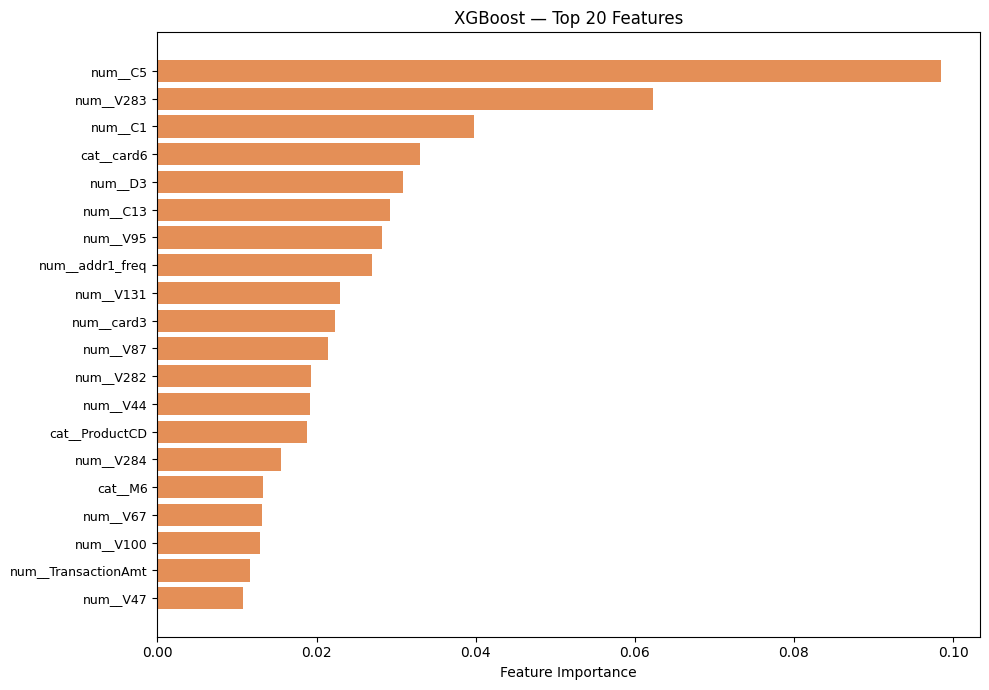

2026/05/05 16:31:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [15]:
import matplotlib.pyplot as plt 
import seaborn as sns

candidates = [(p2,a2,'spw'),(p3,a3,'lr0.05_n200'),(p5,a5,'subsample'),(p6,a6,'min_child')]
best_xgb   = max(candidates, key=lambda x:x[1])
best_xgb_pipeline = best_xgb[0]
print(f'Best XGBoost: {best_xgb[2]} — val_auc={best_xgb[1]:.4f}')

xgb_model   = best_xgb_pipeline.named_steps['model']
importances = xgb_model.feature_importances_
feat_names  = best_xgb_pipeline.named_steps['pre'].get_feature_names_out()
top_idx     = np.argsort(importances)[-20:]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(20), importances[top_idx], color='#e07b39', alpha=0.85)
ax.set_yticks(range(20))
ax.set_yticklabels([feat_names[i] for i in top_idx], fontsize=9)
ax.set_xlabel('Feature Importance')
ax.set_title('XGBoost — Top 20 Features')
plt.tight_layout()
plt.savefig('/kaggle/working/xgb_feature_importance.png', dpi=150)
plt.show()
mlflow.sklearn.save_model(best_xgb_pipeline, '/kaggle/working/xgb_pipeline')

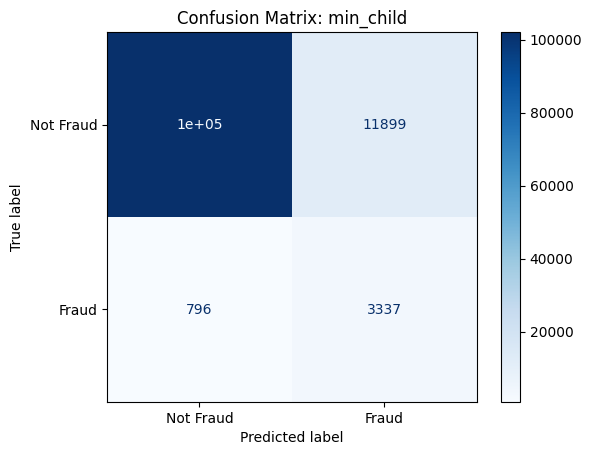

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = best_xgb_pipeline.predict(X_val)

cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Fraud', 'Fraud'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix: {best_xgb[2]}')
plt.show()

In [17]:
with mlflow.start_run(run_name='XGB_Best_Final'):
    mlflow.log_params({
        'n_estimators': 200,
        'learning_rate': 0.05,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'scale_pos_weight': round(spw, 1)
    })
    mlflow.log_metrics({'val_auc': best_xgb[1]})

    mlflow.sklearn.log_model(sk_model=best_xgb_pipeline, name='model', registered_model_name= "IEEEFraud_BestModel")

    run_id = mlflow.active_run().info.run_id
    print(f'New run_id: {run_id}')

print('Registered.')

2026/05/05 16:31:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'IEEEFraud_BestModel' already exists. Creating a new version of this model...
2026/05/05 16:31:35 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: IEEEFraud_BestModel, version 1
Created version '1' of model 'IEEEFraud_BestModel'.


New run_id: c183a99c935140f9907bacb1b284f983
🏃 View run XGB_Best_Final at: https://dagshub.com/lshek22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/c183a99c935140f9907bacb1b284f983
🧪 View experiment at: https://dagshub.com/lshek22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0
Registered.


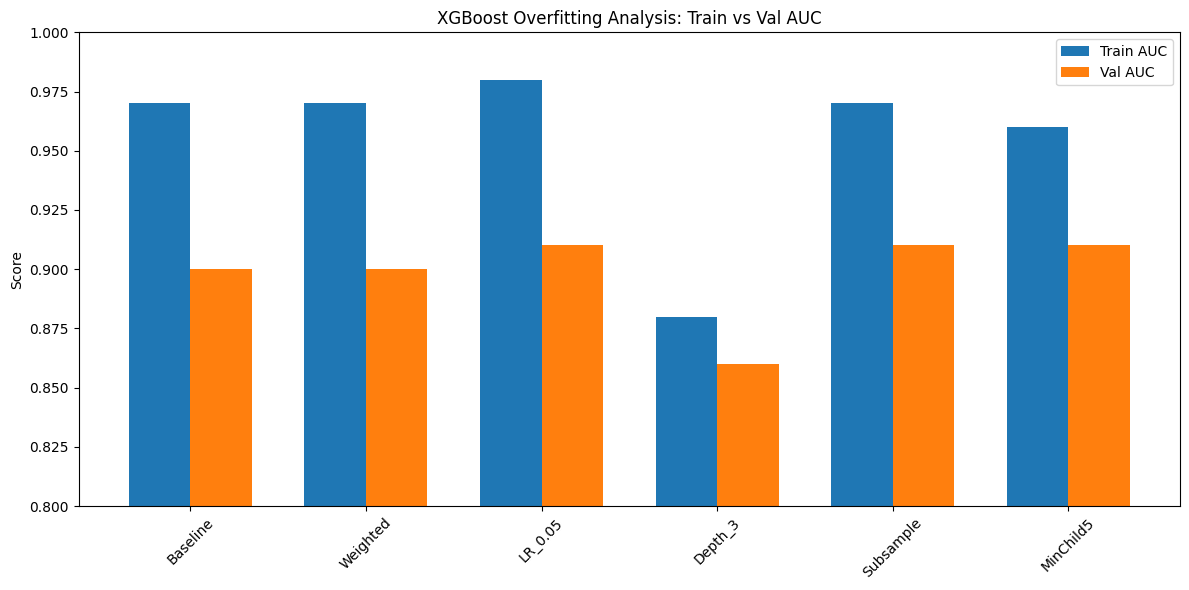

In [1]:
import matplotlib.pyplot as plt
import numpy as np

runs = ['Baseline', 'Weighted', 'LR_0.05', 'Depth_3', 'Subsample', 'MinChild5']
train_auc = [0.97, 0.97, 0.98, 0.88, 0.97, 0.96]
val_auc = [0.90, 0.90, 0.91, 0.86, 0.91, 0.91]

x = np.arange(len(runs))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, train_auc, width, label='Train AUC', color='#1f77b4')
ax.bar(x + width/2, val_auc, width, label='Val AUC', color='#ff7f0e')

ax.set_ylabel('Score')
ax.set_title('XGBoost Overfitting Analysis: Train vs Val AUC')
ax.set_xticks(x)
ax.set_xticklabels(runs, rotation=45)
ax.legend()
ax.set_ylim(0.8, 1.0) 

plt.tight_layout()
plt.savefig('xgb_overfitting_analysis.png', dpi=300)
plt.show()

In [2]:
import matplotlib.pyplot as plt
import xgboost as xgb

model = best_xgb_pipeline.named_steps['model']
importance = model.get_booster().get_score(importance_type='gain')

sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)
top_features = dict(sorted_importance[:15]) 

plt.figure(figsize=(10, 8))
plt.barh(list(top_features.keys()), list(top_features.values()), color='#2c3e50')
plt.xlabel('Importance Score (Gain)')
plt.ylabel('Features')
plt.title('Top 15 Feature Importance - IEEE-CIS Fraud Detection')
plt.gca().invert_yaxis() 


plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=300)
plt.show()

NameError: name 'best_xgb_pipeline' is not defined